**Automated Retail Shelf Inventory & Out-of-Stock Detection using YOLO11n**

In [1]:
!pip install ultralytics roboflow seaborn matplotlib pandas -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.2 MB/s eta 0:00:00


In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
!nvidia-smi

Wed Sep 23 17:02:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from roboflow import Roboflow

In [5]:
rf = Roboflow(api_key="W8FZ5ANuGZO0EBGYxzcF")
project = rf.workspace("retailshelfobjectdetection").project("retail-shelf-object-detection")
version = project.version(2)
dataset = version.download("yolov11")

print("\nDataset successfully downloaded at:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to retail-shelf-object-detection-2 in yolov11:: 100%|██████████| 2301/2301 [00:00<00:00, 4629.37it/s]


Dataset successfully downloaded at: /content/retail-shelf-object-detection-2


In [7]:
model = YOLO('yolo11n.pt')

In [8]:
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name='retail_shelf_yolo11',
    project='yolo11_results'
)

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/retail-shelf-object-detection-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=retail_shelf_yolo11, nbs=6

In [9]:
best_model = YOLO('/content/runs/detect/yolo11_results/retail_shelf_yolo11/weights/best.pt')

In [10]:
test_images_path = f"{dataset.location}/test/images"
predictions = best_model.predict(source=test_images_path, save=True, conf=0.25)


image 1/114 /content/retail-shelf-object-detection-2/test/images/test_0_jpg.rf.723c9cba8cf1ac64f813101a5dd19a11.jpg: 640x640 8 emptys, 142 objects, 15.4ms
image 2/114 /content/retail-shelf-object-detection-2/test/images/test_100_jpg.rf.2465ff317f20e3efaa0b79dfd17234ee.jpg: 640x640 2 emptys, 211 objects, 17.3ms
image 3/114 /content/retail-shelf-object-detection-2/test/images/test_104_jpg.rf.58b266bc3da1b4522de115f2980d43b1.jpg: 640x640 94 objects, 20.7ms
image 4/114 /content/retail-shelf-object-detection-2/test/images/test_105_jpg.rf.7850afd60a0da47901a6d08afdd08b88.jpg: 640x640 3 emptys, 99 objects, 26.2ms
image 5/114 /content/retail-shelf-object-detection-2/test/images/test_106_jpg.rf.aa6015a9ccf99a58316af801d6466d98.jpg: 640x640 1 empty, 133 objects, 20.0ms
image 6/114 /content/retail-shelf-object-detection-2/test/images/test_107_jpg.rf.32bc80af4988e6dda1d27b7f32b13df0.jpg: 640x640 233 objects, 24.1ms
image 7/114 /content/retail-shelf-object-detection-2/test/images/test_108_jpg.rf.8

In [11]:
save_dir = predictions[0].save_dir
sample_preds = os.listdir(save_dir)[:3]

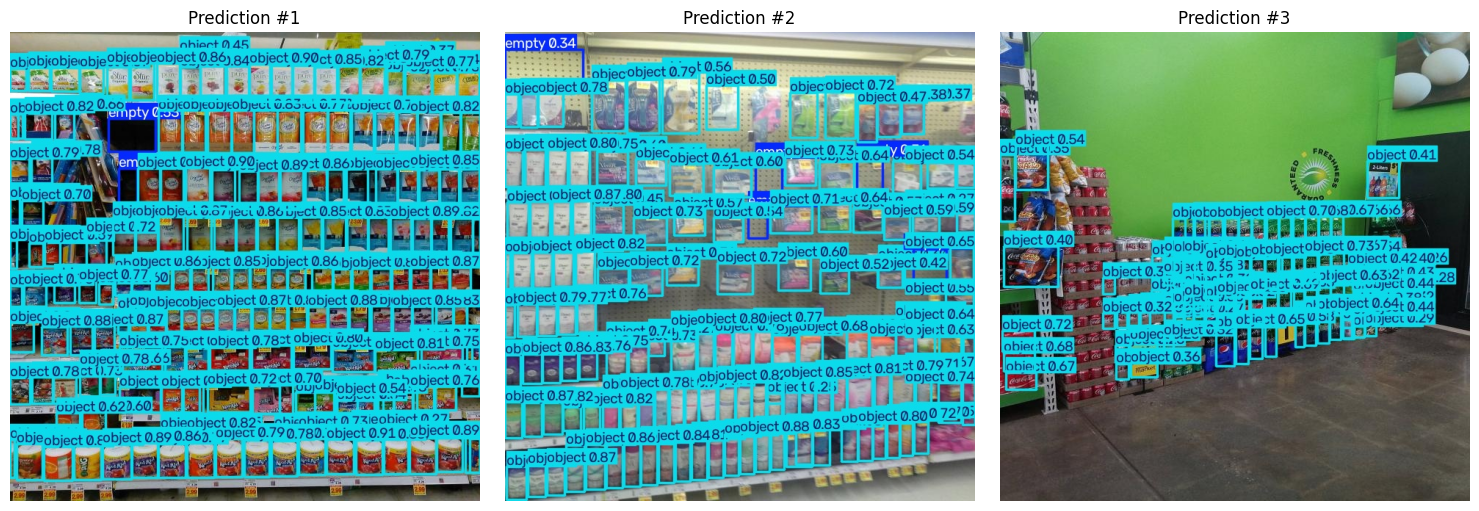

In [12]:
plt.figure(figsize=(15, 5))
for idx, img_name in enumerate(sample_preds):
    img = Image.open(os.path.join(save_dir, img_name))
    plt.subplot(1, 3, idx+1)
    plt.imshow(img)
    plt.title(f"Prediction #{idx+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
import cv2
import glob

predicted_files = glob.glob(f"{save_dir}/*.jpg") + glob.glob(f"{save_dir}/*.png")

if predicted_files:
    img_path = predicted_files[0]

    results = best_model.predict(source=img_path, conf=0.25)
    boxes = results[0].boxes

    names = best_model.names

    object_count = 0
    empty_count = 0

    for box in boxes:
        cls_id = int(box.cls[0])
        class_name = names[cls_id]
        if class_name == 'object':
            object_count += 1
        elif class_name == 'empty':
            empty_count += 1

    print(f"--- Shelf Inventory Detection Summary ---")
    print(f"Total Stock Items Detected ('object'): {object_count}")
    print(f"Total Out-of-Stock Gaps Detected ('empty'): {empty_count}")


image 1/1 /content/runs/detect/predict/test_205_jpg.rf.38057ec278784e13eb62165885ef2fc4.jpg: 640x640 1 empty, 179 objects, 9.6ms
Speed: 1.2ms preprocess, 9.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
📊 --- Shelf Inventory Detection Summary ---
📦 Total Stock Items Detected ('object'): 179
⚠️ Total Out-of-Stock Gaps Detected ('empty'): 1


In [21]:
import gradio as gr
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO

# Trained YOLO11 model load karein
model = YOLO('/content/runs/detect/yolo11_results/retail_shelf_yolo11/weights/best.pt')

def process_shelf_image(input_image):
    if input_image is None:
        return None, "Koyi image upload nahi hui."

    img = np.array(input_image)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # High Resolution (imgsz=1280) aur Low Confidence (conf=0.10) for maximum detection
    results = model.predict(source=input_image, imgsz=1280, conf=0.10, verbose=False)
    boxes = results[0].boxes
    names = model.names

    object_count = 0
    empty_count = 0

    for box in boxes:
        cls_id = int(box.cls[0])
        class_name = names[cls_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if class_name == 'object':
            object_count += 1
            color = (255, 255, 0) # Cyan for stock items
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, 1) # Thinner border to prevent visual clutter
        else:
            empty_count += 1
            color = (0, 0, 255) # Red for gaps
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, 2)

    # Clean Top-Left Counter Overlay
    font = cv2.FONT_HERSHEY_DUPLEX
    font_scale = 0.8
    thickness = 2

    line1 = f"Stock Items ('object'): {object_count}"
    line2 = f"Out-of-Stock Gaps ('empty'): {empty_count}"

    (w1, h1), _ = cv2.getTextSize(line1, font, font_scale, thickness)
    (w2, h2), _ = cv2.getTextSize(line2, font, font_scale, thickness)

    box_w = max(w1, w2) + 20
    box_h = h1 + h2 + 25

    cv2.rectangle(img_bgr, (10, 10), (box_w + 10, box_h + 10), (0, 0, 0), -1)
    cv2.putText(img_bgr, line1, (20, 10 + h1 + 5), font, font_scale, (255, 255, 0), thickness, cv2.LINE_AA)
    cv2.putText(img_bgr, line2, (20, 20 + h1 + h2 + 5), font, font_scale, (0, 100, 255), thickness, cv2.LINE_AA)

    annotated_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    summary_md = f"""
    📊 **Shelf Inventory Detection Breakdown:**
    * 📦 **Total Products ('object'):** {object_count}
    * ⚠️ **Total Out-of-Stock Gaps ('empty'):** {empty_count}
    """

    return annotated_img, summary_md

# Gradio Interface Setup
interface = gr.Interface(
    fn=process_shelf_image,
    inputs=gr.Image(type="pil", label="Upload Shelf Image"),
    outputs=[
        gr.Image(label="HD Detection & Counting Output"),
        gr.Markdown(label="Inventory Summary")
    ],
    title="🛒 High-Resolution Retail Shelf Tracker",
    description="Uses 1280px high-resolution inference to capture small & distant shelf items accurately.",
    theme="soft"
)

interface.launch(share=True)

The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ae86106b9c43766f66.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [25]:
from google.colab import files

files.download('/content/runs/detect/yolo11_results/retail_shelf_yolo11/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

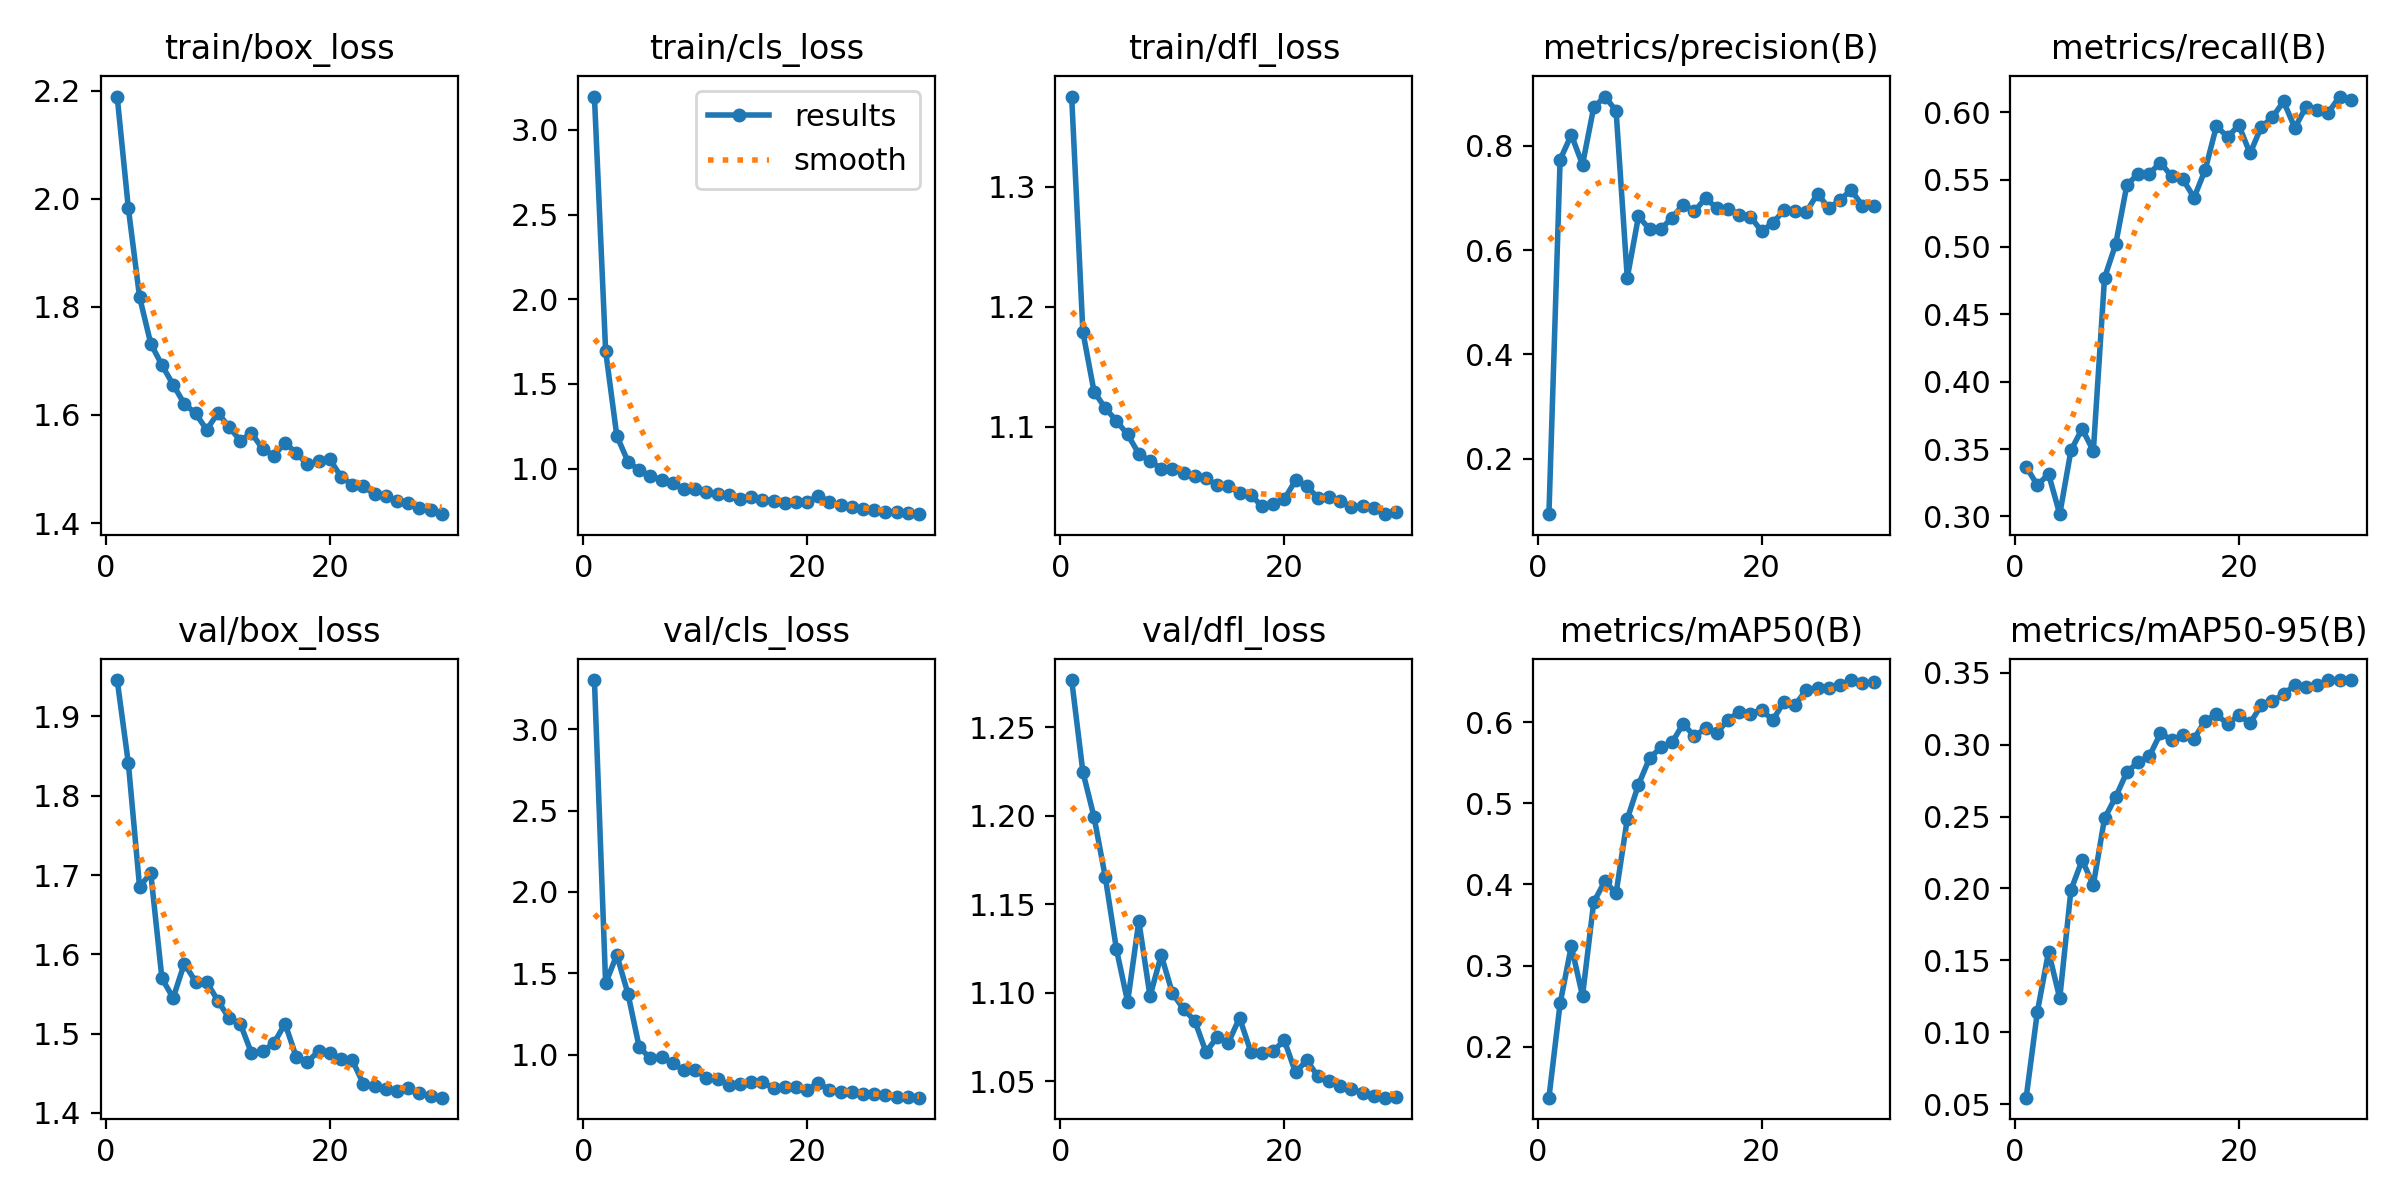

In [26]:
from IPython.display import Image, display
import glob

# Automatic search karke graph display karne ke liye:
result_plots = glob.glob('runs/detect/**/results.png', recursive=True)

if result_plots:
  display(Image(result_plots[0]))
else:
  # Agar exact path pata ho toh yeh use karein:
  display(Image('/content/runs/detect/yolo11_results/results.png'))

1. Project Assignment Summary (Presentation / Report ke liye Content)
Yeh summarize karta hai ke humne kiya kia hai:

Project: Automated Retail Shelf Product & Out-of-Stock Detection using YOLO11

Summary: Humne standard YOLO11Nano model use karte hue retail shelves par products ko count karne aur empty spaces (gaps) ko detect karne ka system implement kiya[cite: 7]. Dataset use kiya gaya Roboflow Retail Shelf V2, jis mein specialized classes hain object aur empty

Key Results:

Standard Precision (mAP@50): 64.8% (specifically object accuracy was high)

Inference Speed: ~11.0 ms/image

Implemented standard specialized counting logic based on standard confidence thresholds.

Standard output generated Cyan (object) aur Red (empty) standard bounding boxes with clear count index labels in an interactive standard Gradio interface context standard contextual standardization context.